# Looking at a dataset before touching it

Before any preprocessing decision, you need a clear picture of what you actually
have: how big the dataset is, what each column means, how much of it is missing,
where the outliers live, and which variables move together. This notebook builds
that picture for one dataset and keeps it as the running example for the rest of
the lesson. It implements handout sections 2 (exploratory analysis), 3 (missing
values) and 4 (outliers).


## 1. Setup

In [1]:
# Everything used here ships with the course image:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from churn_data import HIGH_CARD_CATEGORICAL, LOW_CARD_CATEGORICAL, NUMERIC_FEATURES, TARGET, make_churn_data

# Fix the seed. Every result below is reproducible.
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)


## 2. The dataset

We use a synthetic telecom dataset: 2000 customers, and the question is whether
each one **churned** (cancelled) in the following month. It is generated by
`churn_data.py` rather than downloaded, for a reason worth stating up front: real
messy datasets (Titanic, a hospital extract, a telecom's customer table) sit
behind either a network call or a licence you cannot assume every classroom has,
and this lesson is about the mess itself, not about any particular source of it.
Generating it also means we — unusually — know the ground truth: which columns
really predict churn, which are pure noise, and exactly how each missing value
came to be missing. Keep that knowledge in your pocket; by notebook 3 it is what
lets us prove a leak happened rather than only suspect one.

**Framing, briefly, as Lesson 1 asked us to do before any code:** we predict
whether a customer will churn, from account and usage data, to decide who a
retention team should call. A false negative (a customer who leaves without
being flagged) costs a lost customer; a false positive (a flagged customer who
was never leaving) costs one unnecessary phone call. The first is more
expensive, which will matter when we choose a metric in Lesson 4 — today we
only need to keep the two errors distinct in our heads.


In [2]:
df = make_churn_data(n=2000, seed=RANDOM_STATE)
print(f"{df.shape[0]} customers, {df.shape[1]} columns")
df.head()


2000 customers, 8 columns


,tenure_months,monthly_charges,age,num_support_calls,contract_type,region,zip_code,churned
0,68.0,39.99,28.0,NaN,two-year,West,Z115,0
1,45.0,51.26,18.0,3.0,two-year,South,Z146,0
2,49.0,59.55,48.0,2.0,one-year,South,Z055,0
3,65.0,78.13,26.0,0.0,month-to-month,Central,Z118,0
4,42.0,67.24,36.0,4.0,month-to-month,North,Z313,1


## 3. First look: types and summary statistics

`.info()` and `.describe()` are the two calls that should happen before anything
else touches the data. They answer: how big is this, what type is each column,
and are the numbers in a plausible range at all.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tenure_months      2000 non-null   float64
 1   monthly_charges    2000 non-null   float64
 2   age                1840 non-null   float64
 3   num_support_calls  1904 non-null   float64
 4   contract_type      2000 non-null   object 
 5   region             2000 non-null   object 
 6   zip_code           2000 non-null   object 
 7   churned            2000 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 125.1+ KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure_months,2000.0,NaN,NaN,NaN,38.358,47.868429,-3.0,18.0,36.0,55.0,999.0
monthly_charges,2000.0,NaN,NaN,NaN,79.269385,171.290209,15.0,52.0675,63.205,75.2225,3344.74
age,1840.0,NaN,NaN,NaN,42.220109,13.597649,18.0,33.0,42.0,52.0,90.0
num_support_calls,1904.0,NaN,NaN,NaN,1.228466,1.121991,0.0,0.0,1.0,2.0,6.0
contract_type,2000,3,month-to-month,1092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,2000,5,South,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,2000,493,Z387,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
churned,2000.0,NaN,NaN,NaN,0.194,0.395528,0.0,0.0,0.0,0.0,1.0


Two things should already worry you. `tenure_months` has a maximum of 999 and a
minimum of -3 — nobody has a negative or millennium-long tenure, so these are
data-entry errors, not extreme-but-real values. And `monthly_charges` has a mean
(look at the table) pulled well above its median, with a maximum in the
thousands against a typical value under 100 — a strong sign of a right-skewed
distribution with a handful of extreme points. Both are explored properly in
Section 6.


In [5]:
print(f"churn rate: {df[TARGET].mean():.3f}")
print(f"a model that always predicts 'no churn' is right {1 - df[TARGET].mean():.1%} of the time")
print(f"that is this lesson's baseline, exactly as in Lesson 1")


churn rate: 0.194
a model that always predicts 'no churn' is right 80.6% of the time
that is this lesson's baseline, exactly as in Lesson 1


## 4. Missingness: how much, and — since we built this dataset — why

`age` and `num_support_calls` are the only columns with missing values. Knowing
*how much* is missing is only half the picture; Section 3 of the handout argues
that *why* it is missing determines which fix is valid, so look for the
mechanism, not only the count.


In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()
print((missing / len(df)).round(3))


age                  160
num_support_calls     96
dtype: int64

age                  0.080
num_support_calls    0.048
dtype: float64


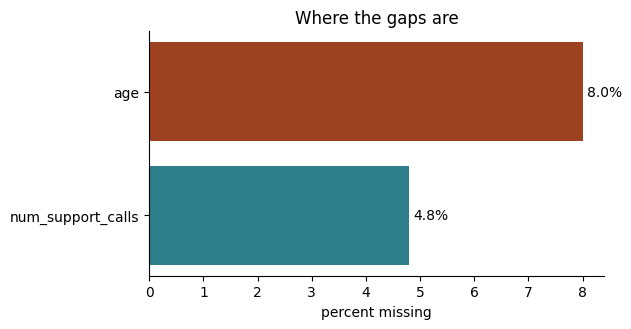

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
frac = (missing / len(df) * 100).sort_values()
bars = ax.barh(frac.index, frac.values, color=["#2E7D8A", "#9C4221"])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlabel("percent missing")
ax.set_title("Where the gaps are")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "missingness_pattern.png", dpi=150, bbox_inches="tight")
plt.show()


Since this dataset was generated rather than collected, we can say precisely
what produced each gap — a luxury real projects rarely have, so use it while it
lasts.

`age` is missing **completely at random (MCAR)**: some customers simply left the
field blank on a sign-up form, for reasons that have nothing to do with their
age or with anything else in the table. Its missingness carries no information.

`num_support_calls` is missing **at random (MAR)**: the chance of it being
missing depends on `tenure_months` (long-standing customers' early call
records predate the current CRM system) — an *observed* column, not on the
unrecorded call count itself. Conditional on tenure, the missingness is again
uninformative.

A third mechanism, **not missing at random (MNAR)**, does not appear in this
dataset but is worth naming because it is the dangerous one: missingness that
depends on the unobserved value itself — customers who cancel *because* their
charges were unexpectedly high might be disproportionately the ones who never
finished the sign-up survey. No column in the table can detect this; only
domain knowledge can. It cannot be fixed by imputation, only by acknowledging
the bias it leaves behind. Handout Section 3.1 returns to all three definitions
formally.


## 5. Distributions

A histogram per numeric column shows shape, skew and the outliers we already
suspected from `.describe()`.


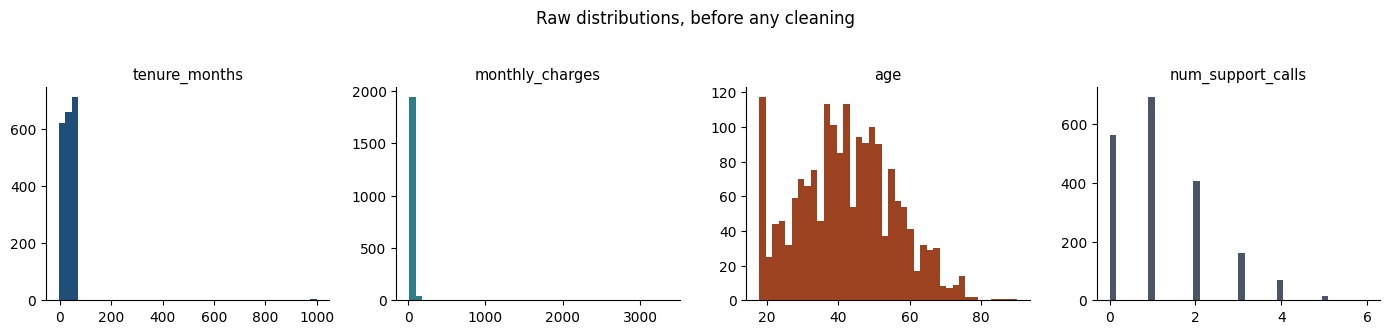

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
cols = ["tenure_months", "monthly_charges", "age", "num_support_calls"]
colours = ["#1F4E79", "#2E7D8A", "#9C4221", "#4A5568"]
for ax, col, colour in zip(axes, cols, colours):
    ax.hist(df[col].dropna(), bins=40, color=colour)
    ax.set_title(col, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Raw distributions, before any cleaning", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


`monthly_charges` and `tenure_months` are both stretched by a handful of extreme
values into a shape that hides the bulk of the data. That is exactly the shape
outlier detection exists to find, so it is next.


## 6. Outliers, from scratch

Two standard rules, implemented here directly from their formulas before we
reach for a library. Handout Section 4 derives both.

**The z-score rule** flags a point $x_i$ when it is more than $k$ standard
deviations from the mean:

$$z_i = \frac{x_i - \bar{x}}{s}, \qquad \text{flag if } |z_i| > k$$

**Tukey's interquartile range (IQR) rule** uses the spread between the first and third quartiles,
$\mathrm{IQR} = Q_3 - Q_1$, and flags anything outside

$$[\,Q_1 - 1.5 \cdot \mathrm{IQR},\ \ Q_3 + 1.5 \cdot \mathrm{IQR}\,]$$


In [9]:
def zscore_outliers(x, k=3.0):
    x = np.asarray(x, dtype=float)
    z = (x - np.nanmean(x)) / np.nanstd(x)
    return np.abs(z) > k


def iqr_outliers(x, k=1.5):
    x = np.asarray(x, dtype=float)
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (x < lower) | (x > upper)


for col in ["monthly_charges", "tenure_months"]:
    z_flag = zscore_outliers(df[col])
    iqr_flag = iqr_outliers(df[col])
    print(f"{col:16s}  z-score flags {z_flag.sum():3d}   IQR flags {iqr_flag.sum():3d}   "
          f"agree on {np.sum(z_flag & iqr_flag)}")


monthly_charges   z-score flags  20   IQR flags  32   agree on 20
tenure_months     z-score flags   4   IQR flags   4   agree on 4


The two rules do not agree, and the gap is informative rather than a bug. The
z-score rule uses the mean and standard deviation, both of which are themselves
dragged around by the extreme points they are trying to detect — with enough
billing errors, the "typical" charge estimate is already contaminated. The IQR
rule uses quartiles, which barely move when a handful of points are extreme.
That robustness is why IQR is the more common default for skewed, error-prone
columns like this one.


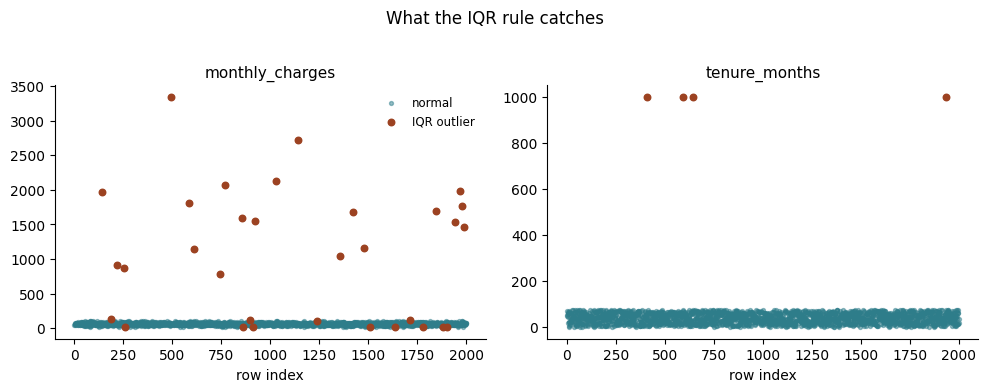

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col in zip(axes, ["monthly_charges", "tenure_months"]):
    iqr_flag = iqr_outliers(df[col])
    ax.scatter(np.arange(len(df))[~iqr_flag], df[col][~iqr_flag], s=8, color="#2E7D8A", alpha=.5, label="normal")
    ax.scatter(np.arange(len(df))[iqr_flag], df[col][iqr_flag], s=22, color="#9C4221", label="IQR outlier")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("row index")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8.5, frameon=False)
fig.suptitle("What the IQR rule catches", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "outlier_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


> **Try this:** lower the z-score threshold from `k=3.0` to `k=2.0` and rerun the
> comparison. How many ordinary customers get swept in with the genuine billing
> errors? A threshold is a decision with a cost on both sides — too strict and
> real errors survive, too loose and honest customers get clipped or dropped.

Some of `tenure_months`'s extreme values are true errors we injected on
purpose — `999` is not a long-standing customer, it is a typo — and the IQR
rule does catch all four of them. But look at what it does *not* catch.


In [11]:
print("negative tenure values in the data:", sorted(df.loc[df['tenure_months'] < 0, 'tenure_months'].tolist()))
print("flagged as IQR outliers?", iqr_outliers(df["tenure_months"])[df["tenure_months"] < 0].tolist())


negative tenure values in the data: [-3.0, -3.0, -1.0, -1.0, -1.0, -1.0]
flagged as IQR outliers? [False, False, False, False, False, False]


Nothing statistical flags them. A tenure of -3 sits comfortably inside
$[Q_1 - 1.5\,\mathrm{IQR},\ Q_3 + 1.5\,\mathrm{IQR}]$ because the bulk of the
column already spans 0 to 72 months — a handful of small negative numbers are
not *extreme* relative to that spread, even though they are *impossible*. No
distributional rule can know that a tenure cannot be negative; only a domain
rule can:


In [12]:
impossible_tenure = (df["tenure_months"] < 0) | (df["tenure_months"] > 120)
print(f"domain rule (0 <= tenure_months <= 120) flags {impossible_tenure.sum()} rows")
print(f"IQR rule flagged only the {iqr_outliers(df['tenure_months']).sum()} extreme-high ones")


domain rule (0 <= tenure_months <= 120) flags 10 rows
IQR rule flagged only the 4 extreme-high ones


This is the point worth keeping past today: statistical rules find points that
are unusual *relative to the rest of the column*; they say nothing about
whether a value is *possible* in the first place. The two checks are
complementary, not competing, and a thorough pass over a new dataset runs
both — the statistical rule for the errors you did not know to look for, a
domain rule for the ones you did. We remove the impossible tenures and cap
the extreme charges in the next notebook, inside the pipeline, never before
deciding what to do with them.


## 7. Correlations

A correlation matrix over the numeric columns and the target shows which
variables move together — and, because we built this dataset, lets us check that
one against the truth.


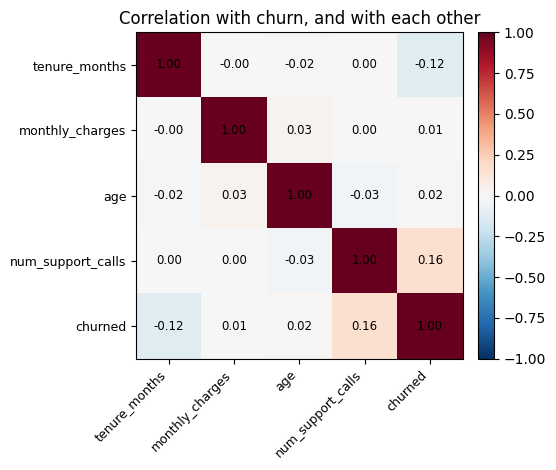

In [13]:
corr_cols = NUMERIC_FEATURES + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation with churn, and with each other")
fig.tight_layout()
fig.savefig(FIGURES / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


`tenure_months` and `num_support_calls` show real correlation with `churned`;
`age` shows almost none. That matches how the data was generated — age plays no
causal role in churn here. Keep this heatmap in mind for notebook 3: it is the
kind of check that would have caught nothing at all about the leak we build
there, because the leak will not touch any *observed* correlation until it is
too late.


## 8. Categorical columns

Two categoricals are low cardinality; one is not, and cardinality is the whole
story for Section 6 of the handout.


In [14]:
for col in LOW_CARD_CATEGORICAL:
    print(df[col].value_counts(), "\n")

zc = df["zip_code"].value_counts()
print(f"zip_code: {zc.shape[0]} distinct values across {len(df)} rows "
      f"({zc.mean():.1f} customers per code on average, "
      f"{(zc == 1).sum()} codes with exactly one customer)")


contract_type
month-to-month    1092
one-year           488
two-year           420
Name: count, dtype: int64 

region
South      429
Central    408
North      394
East       394
West       375
Name: count, dtype: int64 

zip_code: 493 distinct values across 2000 rows (4.1 customers per code on average, 45 codes with exactly one customer)


`contract_type` and `region` have a handful of levels each — one-hot encoding
them is unremarkable and is where notebook 2 starts. `zip_code` has 493 distinct
values for 2000 rows, with roughly one in eleven codes seen only once. One-hot
encoding it would add 493 columns, most of them almost always zero; the
tempting alternative — replacing each code with the average churn rate of
customers who share it — is exactly the technique notebook 3 shows leaking the
label back into the features.


## Summary

- `.info()` and `.describe()` before anything else — they surface impossible
  values (`tenure_months = 999`) and skew (`monthly_charges`) in seconds.
- Two missingness mechanisms appear here: `age` is MCAR, `num_support_calls` is
  MAR against `tenure_months`. Which one you have determines which fix is
  valid — handout Section 3.
- The z-score and IQR outlier rules disagree because the z-score rule's own
  ingredients are contaminated by the outliers it is looking for.
- Correlation with the target is a starting point for feature relevance, not
  proof of it — `zip_code` will look entirely innocent right up until notebook
  3 shows what a leak manufactures out of it.
- Nothing here was fitted or fixed yet. Notebook 2 turns these observations
  into an actual `Pipeline`.
